In [49]:
#!pip install matplotlib

In [57]:
import numpy as np
import time
import torch
import time
import sys
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [ ]:
# Generate Networks

In [19]:
import numpy as np
import networkx as nx
from scipy.stats import nbinom
import matplotlib.pyplot as plt
import secrets
# ---------------- Utilidades para generar grafos ----------------
def generate_degrees(n, mean_k, var_k):
    """Genera una secuencia de grados con media y varianza aproximadas.
    This function's primary role is to create a sequence of degrees for a graph with $n$ nodes,
    ensuring the sequence adheres to a desired average degree ($\text{mean\_k}$) and
    degree variability ($\text{var\_k}$).
    It achieves this by sampling from a Negative Binomial distribution
    (a common choice for modeling real-world networks) and then performs necessary clean-up steps:
    it clips the degrees to be positive and less than $n$, and it adjusts one degree
    by $\pm 1$ if the total sum of degrees is odd, which is a mathematical requirement
    for a simple graph to exist.
    """


    if var_k <= mean_k:
        raise ValueError("La varianza debe ser mayor que la media para la Negativa Binomial.")
    p = mean_k / var_k
    r = mean_k * p / (1 - p)
    degs = nbinom(r, p).rvs(size=n)
    degs = np.clip(degs, 1, n-1)
    if np.sum(degs) % 2 == 1:
        idx = np.random.randint(0, n)
        degs[idx] += 1 if degs[idx] < n-1 else -1
    return degs

def ensure_connected(G):
    """Ensure the graph is connected by linking components if necessary.
    This function guarantees that the input graph $G$ is a single, unified component.
    It first checks if the graph is already connected. If it is not, it iterates through all
    separate connected components, randomly selecting one node from each pair of adjacent
    components and adding a single edge between them until the entire graph is connected.
    This ensures that the final graph structure is ready for analysis or simulation that
    requires connectivity.


    """
    if nx.is_connected(G):
        return G

    components = list(nx.connected_components(G))
    # Connect components sequentially with random nodes from each
    for i in range(len(components) - 1):
        u = np.random.choice(list(components[i]))
        v = np.random.choice(list(components[i + 1]))
        G.add_edge(u, v)

    assert nx.is_connected(G)
    return G

def generate_connected_graph(n=500, mean_k=6, var_k=20, seed=None):
    """Genera un grafo conexo con la secuencia de grados objetivo.
    This is the main execution function that generates a complete, connected graph with
    specific size and degree properties. It first sets the random seed for reproducibility.
    It then calls generate_degrees to create the target degree sequence and uses
    a network construction algorithm like $\text{Havel-Hakimi}$ or
    $\text{Configuration Model}$ (from $\text{NetworkX}$) to build the graph based on those degrees.
    Finally, it calls ensure_connected
    to guarantee the resulting graph is usable, returning the final, fully-constructed graph $G$.
    """
    np.random.seed(seed)
    degrees = generate_degrees(n, mean_k, var_k)
    try:
        G = nx.havel_hakimi_graph(degrees)
    except nx.NetworkXError:
        G = nx.configuration_model(degrees)
        G = nx.Graph(G)
        G.remove_edges_from(nx.selfloop_edges(G))
    G = ensure_connected(G)
    return G

def generate_secure_seed():
    """
    Generates a cryptographically secure, 32-bit integer.
    This range (0 to 2**32 - 1) is fully compatible with np.random.seed().
    """
    return secrets.randbits(32)

<>:10: SyntaxWarning: invalid escape sequence '\_'
<>:10: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_7372/5310333.py:10: SyntaxWarning: invalid escape sequence '\_'
  ensuring the sequence adheres to a desired average degree ($\text{mean\_k}$) and


## Kuramoto Model

In [20]:
import torch
import numpy as np
from typing import List
import tqdm

Complex = torch.complex128

class KuramotoFast:
    def __init__(self, n_nodes: int, n_oscillators: int, sampling_rate: int, k_list: List[float], weight_matrix: np.ndarray,
                 frequency_spread: float, noise_scale: float=1.0, use_cuda: bool=True, use_tqdm: bool=True, node_frequencies=None, **kwargs):
        """
            Implementation of nested Kuramoto model using PyTorch. The model consists of N nodes each with M oscillators. Each pair of nodes is connected with directed weight given by weight_matrix.

            :param n_nodes: number of nodes in the model
            :param n_oscillators: number of oscillators in each node
            :param sampling_rate: update rate of the model
            :param k_list: list of K values (within node shift) of the model. Should have length equal to number of nodes.
            :param weight_matrix: 2d matrix of node vs node connectivity weight. Should have N_nodes x N_nodes shape.
            :param frequency_spread: spread of frequencies within a node. Frequencies of oscillators are defined as linspace from central_frequency - frequency_spread to central_frequency + frequency_spread
            :param noise_scale: sigma of noise.
            :param use_cuda: use GPU (PyTorch CUDA/ROCm) to compute the model?
        """
        self._check_parameters(n_nodes, k_list, weight_matrix)

        # Set device
        if use_cuda and torch.cuda.is_available():
            self.device = torch.device("cuda")
            device_name = "GPU (CUDA/ROCm)"
        else:
            self.device = torch.device("cpu")
            device_name = "CPU"
        print(f"Using device: {device_name}")

        self.n_nodes = n_nodes
        self.n_oscillators = n_oscillators
        self.k_list = k_list
        self.noise_scale = 2 * np.pi * noise_scale / sampling_rate

        self.frequency_spread = frequency_spread
        self.node_frequencies = node_frequencies

        # Convert weight_matrix to PyTorch tensor
        self.weight_matrix = torch.tensor(weight_matrix, dtype=torch.float64, device=self.device)
        torch.diagonal(self.weight_matrix).fill_(0)  # Set diagonal to 0
        self.weight_matrix = self.weight_matrix.T  # Transpose for directed connectivity

        self.sampling_rate = sampling_rate
        self.dt = 1.0 / sampling_rate
        self.use_cuda = use_cuda
        self.disable_tqdm = not(use_tqdm)

        self._init_parameters()
        self._preallocate()

    def _check_parameters(self, n_nodes: int, k_list: List[float], weight_matrix: np.ndarray):
        if len(k_list) != n_nodes:
            raise RuntimeError(f'Size of k_list ({len(k_list)}) is not equal to number of nodes ({n_nodes}).')
        if np.ndim(weight_matrix) != 2 or (weight_matrix.shape[0] != weight_matrix.shape[1]):
            raise RuntimeError(f'weight_matrix should be a 2d square matrix, got {weight_matrix.shape} shape.')
        if weight_matrix.shape[0] != n_nodes or weight_matrix.shape[1] != n_nodes:
            raise RuntimeError(f'weight matrix should be a 2d matrix of size N_nodes x N_nodes, got {weight_matrix.shape} shape')

    def _init_parameters(self):
        # Angular frequencies in rad/s
        omegas = torch.zeros((self.n_nodes, self.n_oscillators), dtype=torch.float64, device=self.device)
        for idx, frequency in enumerate(self.node_frequencies):
            freq_lower = frequency - self.frequency_spread
            freq_upper = frequency + self.frequency_spread
            omegas[idx] = torch.linspace(freq_lower, freq_upper, steps=self.n_oscillators, device=self.device, dtype=torch.float64)

        omegas += torch.rand(omegas.shape, device=self.device, dtype=torch.float64) * 0.2 - 0.1  # Uniform [-0.1, 0.1]
        self.omegas = omegas * 2 * np.pi  # rad/s

        # Shift coeffs
        C = torch.tensor(self.k_list, dtype=torch.float64, device=self.device) / self.n_oscillators
        self.shift_coeffs = C.view(-1, 1)

        # Random initial phase
        thetas = torch.rand(omegas.shape, device=self.device, dtype=torch.float64) * 2 * np.pi - np.pi  # Uniform [-π, π]
        self.phases = torch.exp(1j * thetas)

        self._complex_dtype = torch.complex64
        self._float_dtype = torch.float32

    def _preallocate(self):
        n_nodes, n_osc = self.phases.shape
        self._phase_conj = torch.empty_like(self.phases)
        self._external_buffer = torch.empty((n_nodes, n_nodes, n_osc), dtype=self.phases.dtype, device=self.device)

    def _compute_rhs(self, phases):
        mean_phase = torch.mean(phases, dim=1)  # Shape: (n_nodes,)
        self._phase_conj = torch.conj(phases)  # Shape: (n_nodes, n_oscillators)

        # External dynamics
        # tensordot computes outer product: (n_nodes, n_oscillators) × (n_nodes,) → (n_nodes, n_oscillators, n_nodes)
        # permute reorders to (n_nodes, n_nodes, n_oscillators)
        self._external_buffer = torch.tensordot(self._phase_conj, mean_phase, dims=0).permute(0, 2, 1)
        weight_expanded = self.weight_matrix[:, :, None].expand(-1, -1, self.n_oscillators)  # Shape: (n_nodes, n_nodes, n_oscillators)
        self._external_buffer *= weight_expanded
        external = self._external_buffer.sum(dim=1)  # Shape: (n_nodes, n_oscillators)
        external_rhs = external.imag / self.n_nodes

        # Internal dynamics
        self._phase_conj = phases * torch.sum(self._phase_conj, dim=1, keepdim=True)
        self._phase_conj = torch.conj(self._phase_conj)
        internal_rhs = self._phase_conj.imag * self.shift_coeffs

        rhs = self.omegas + internal_rhs + external_rhs
        return rhs

    def simulate(self, time: float, noise_realisations: int=100, random_seed: int=42) -> np.ndarray:
        """
            Implementation of nested Kuramoto model with RK4 integration using PyTorch.

            :param time: Length of the simulation in seconds. Total number of samples is computed as sampling_rate x time + 1 (initial state)
            :param noise_realisations: Number of noise realisations to generate (not used in this version)
            :return: N_nodes x N_ts matrix of complex values that contains each node activity during the simulation
        """
        torch.manual_seed(random_seed)
        n_iters = int(time * self.sampling_rate)
        history = torch.zeros((self.n_nodes, n_iters + 1), dtype=self._complex_dtype, device=self.device)
        history[:, 0] = self.phases.mean(dim=1)

        for i in tqdm.trange(1, n_iters + 1, leave=False, desc='Kuramoto model is running...', disable=self.disable_tqdm):
            # RK4 steps
            k1 = self._compute_rhs(self.phases)
            phases2 = self.phases * torch.exp(1j * (self.dt / 2) * k1)
            k2 = self._compute_rhs(phases2)
            phases3 = self.phases * torch.exp(1j * (self.dt / 2) * k2)
            k3 = self._compute_rhs(phases3)
            phases4 = self.phases * torch.exp(1j * self.dt * k3)
            k4 = self._compute_rhs(phases4)
            rhs = (k1 + 2 * k2 + 2 * k3 + k4) / 6

            shift_noise = torch.normal(mean=0.0, std=self.noise_scale, size=rhs.shape, device=self.device, dtype=torch.float64)
            rhs += shift_noise
            self.phases *= torch.exp(1j * self.dt * rhs)
            history[:, i] = self.phases.mean(dim=1)

        # Convert to NumPy for return
        history = history.cpu().numpy()
        return history

# Some other functions

In [36]:
from numpy.polynomial.polynomial import polyfit, polyval

def FA_metric(phasor, scales):
    """ y: cummulative sum, and scales should be defined"""
    y = calc_detrened(phasor)
    F_fa = np.zeros(len(scales))
    
    for i, s in enumerate(scales):

        diffs = y[s:] - y[:-s]
        F_fa[i] = np.sqrt(np.mean(diffs**2))

    # Fit log–log slope
    coeff_fa = np.polyfit(np.log2(scales), np.log2(F_fa), 1)
    alpha_fa = coeff_fa[0]
    fit_fa = 2 ** np.polyval(coeff_fa, np.log2(scales))

    # plt.figure(figsize=(7, 5))
    # plt.loglog(scales, F_fa, 'o', label="FA Data")
    # plt.loglog(scales, fit_fa, 'r--', label=f"Fit: α = {alpha_fa:.2f}")
    # plt.title("Fluctuation Analysis (FA)")
    # plt.xlabel("log₂(Window size s)")
    # plt.ylabel("log₂(Fluctuation F(s))")
    # plt.legend()
    # plt.grid(True, which="both", ls="--")
    # plt.show()

    print(f"Estimated FA exponent α = {alpha_fa:.3f}")

    return fit_fa, alpha_fa

def calc_detrened(data):
    x = np.abs(data)
    y = np.cumsum(x - np.mean(x))

    return y

def dfa_rms(y, scale):
    n_windows = len(y) // scale

    if n_windows == 0:
        return np.nan  # scale too large
        
    shape = (n_windows, scale)
    Y = np.lib.stride_tricks.as_strided(y, shape=shape)
    rms = np.zeros(n_windows)
    scale_axis = np.arange(scale)

    for i, window in enumerate(Y):
        coeff = np.polyfit(scale_axis, window, 1)
        trend = np.polyval(coeff, scale_axis)
        rms[i] = np.sqrt(np.mean((window - trend) ** 2))
    return np.mean(rms)


def dfa_scales(min_exp=5, max_exp=9, step=0.25):
    """
    Logarithmic scales: 2^5 ... 2^9 in reasonable increments.
    Ensures scales are strictly increasing and unique.
    """
    scales = np.round(2 ** np.arange(min_exp, max_exp, step)).astype(int)
    scales = np.unique(scales)
    return scales

def DFA(data):
    """
    Full DFA1 for a complex phasor time series.
    Returns (alpha, scales, F)
    """
    y = calc_detrened(data)
    scales = dfa_scales()

    F = []
    for s in scales:
        rms_val = dfa_rms(y, s)
        if not np.isnan(rms_val):
            F.append(rms_val)
        else:
            F.append(np.nan)

    F = np.array(F)

    # Remove invalid scales
    mask = ~np.isnan(F)
    scales = scales[mask]
    F = F[mask]

    coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
    alpha = coeff[0]

    return alpha, scales, F


In [22]:
def plv_func(x, y):
    x_f = x / np.abs(x)
    y_f = y / np.abs(y)
    plv_values = 1/len(x_f) * np.dot(x_f, np.conj(y_f))
    return np.abs(plv_values)

# New function
def plv_matrix_vectorized(inst_theta):
    X = np.exp(1j * inst_theta)          # (T, N)
    M = np.dot(X.conj().T, X) / X.shape[0]
    return np.abs(M)

In [17]:
## START

In [7]:
# --- Generate the seeds ---
num_networks = 4
num_replicas = 3
random_seeds = [generate_secure_seed() for _ in range(num_networks)]

# --- Define parameters ---
N = 500  # constant for all graphs
mean_k_values = [10, 10, 40, 40] # low, low, high, high mean
var_k_values  = [14, 100, 44, 100] # low, high , low, high variance
seed_values   = random_seeds

# --- Preallocate array for adjacency matrices ---
all_adj = np.zeros((num_networks, num_replicas, N, N), dtype=int)

# --- Generate all graphs and replicas ---
for i, (mean_k, var_k, seed) in enumerate(zip(mean_k_values, var_k_values, seed_values)):

    for r in range(num_replicas):
        print(f"Generating network {i+1}/{num_networks}, replica {r+1}/{num_replicas}")

        # Each replica can vary by changing the random seed
        replica_seed = generate_secure_seed()  # just offset to ensure different randomizations

        graph = generate_connected_graph(
            n=N,
            mean_k=mean_k,
            var_k=var_k,
            seed=replica_seed
        )

        A = nx.to_numpy_array(graph, dtype=int)
        all_adj[i, r] = A

# # --- Save locally ---
np.save("adjacency_matrices.npy", all_adj)
# # or compressed
np.savez_compressed("adjacency_matrices.npz", adjacency_matrices=all_adj)

Generating network 1/4, replica 1/3
Generating network 1/4, replica 2/3
Generating network 1/4, replica 3/3
Generating network 2/4, replica 1/3
Generating network 2/4, replica 2/3
Generating network 2/4, replica 3/3
Generating network 3/4, replica 1/3
Generating network 3/4, replica 2/3
Generating network 3/4, replica 3/3
Generating network 4/4, replica 1/3
Generating network 4/4, replica 2/3
Generating network 4/4, replica 3/3


In [8]:
all_adj.shape

(4, 3, 500, 500)

0 0


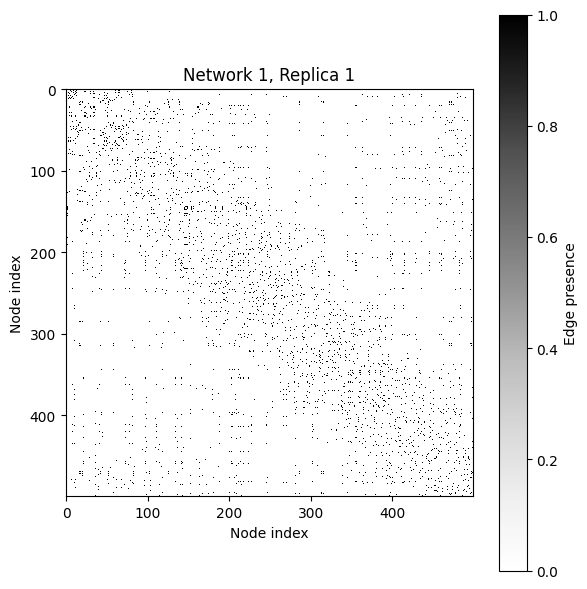

0 1


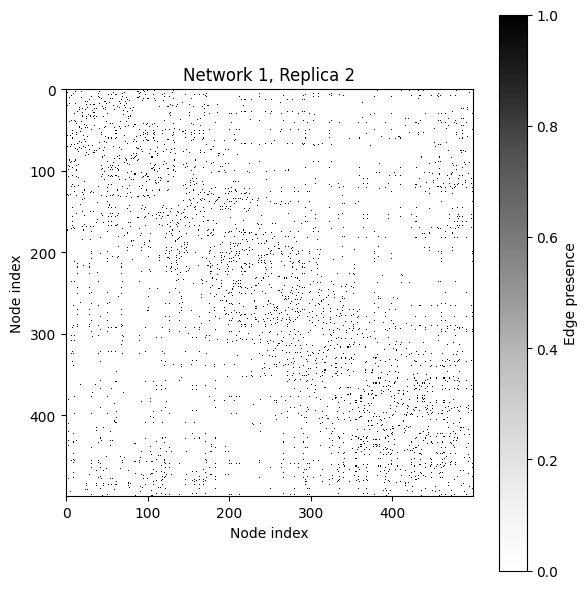

0 2


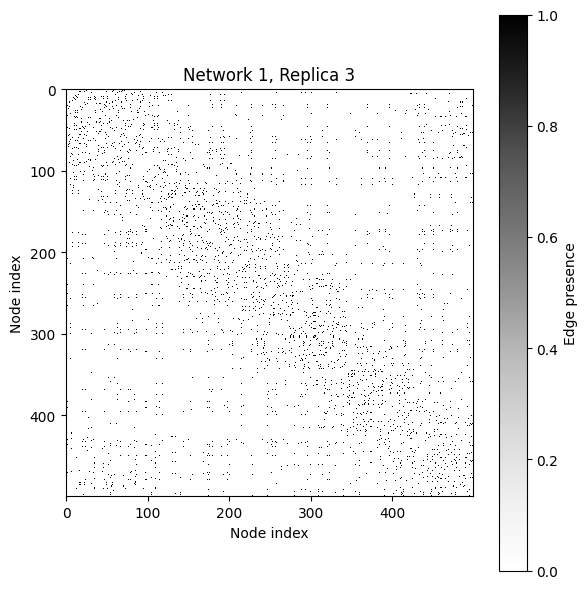

1 0


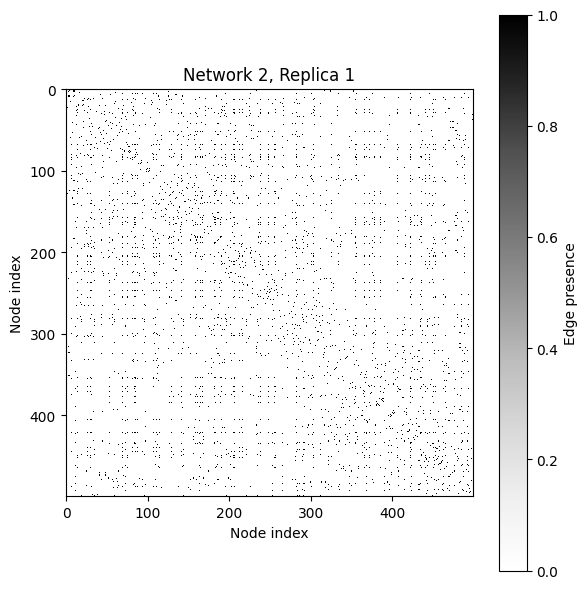

1 1


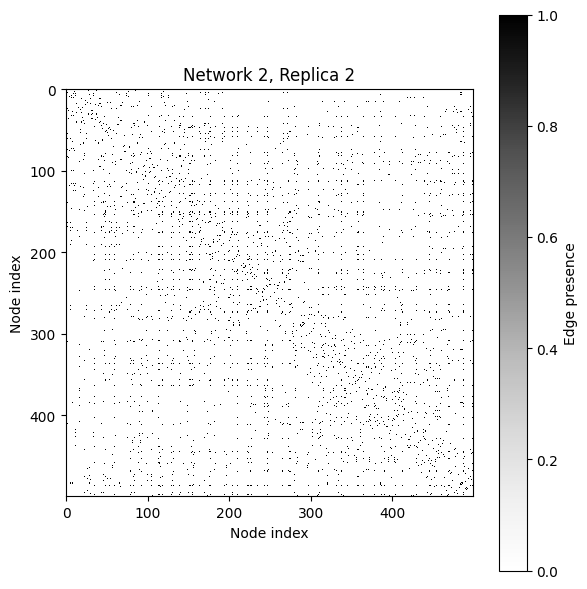

1 2


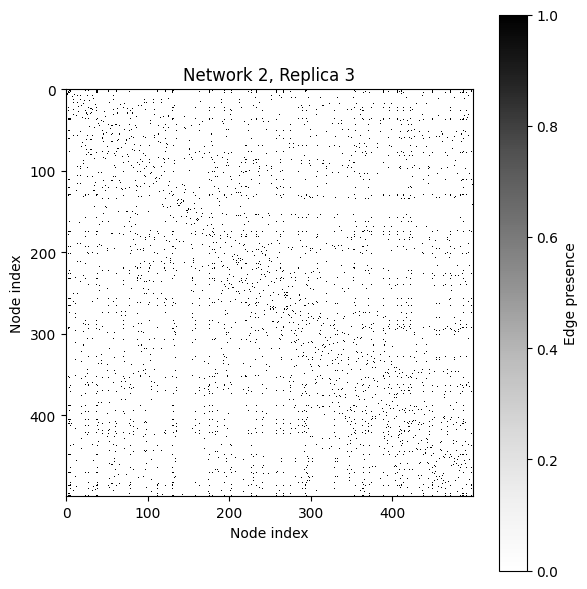

2 0


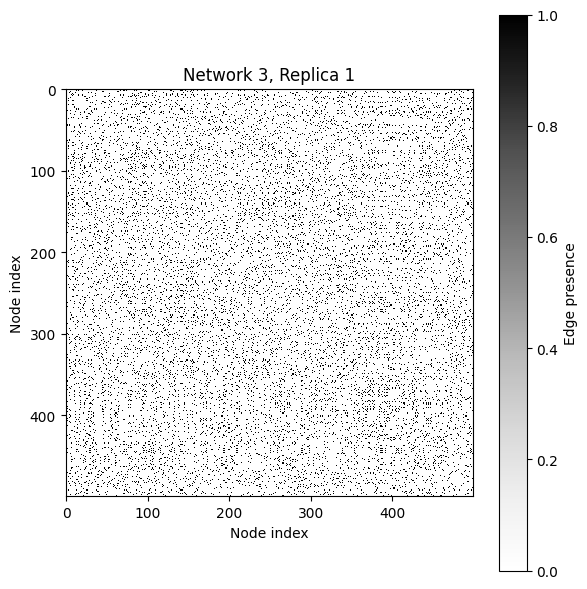

2 1


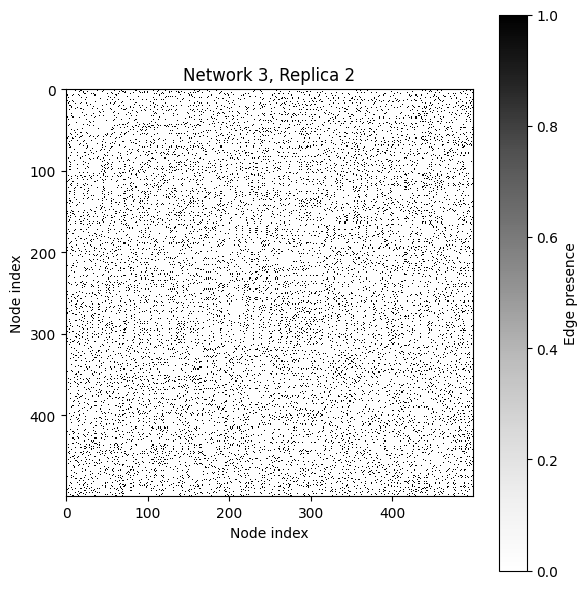

2 2


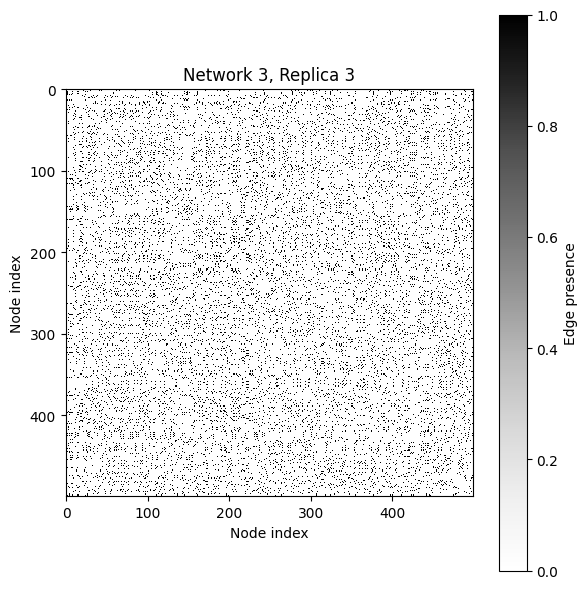

3 0


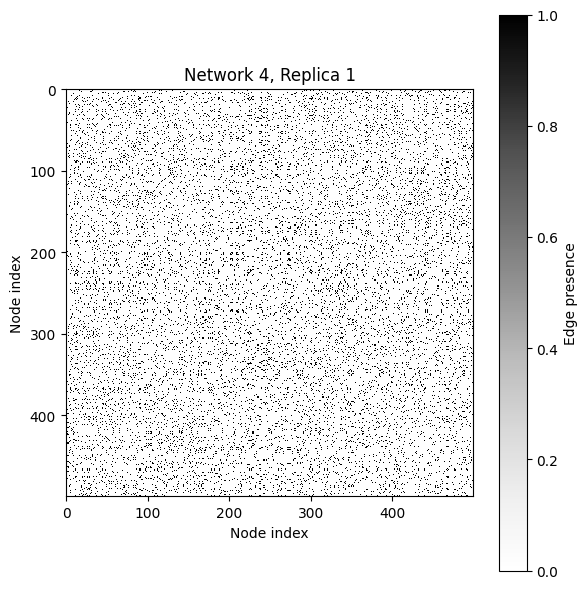

3 1


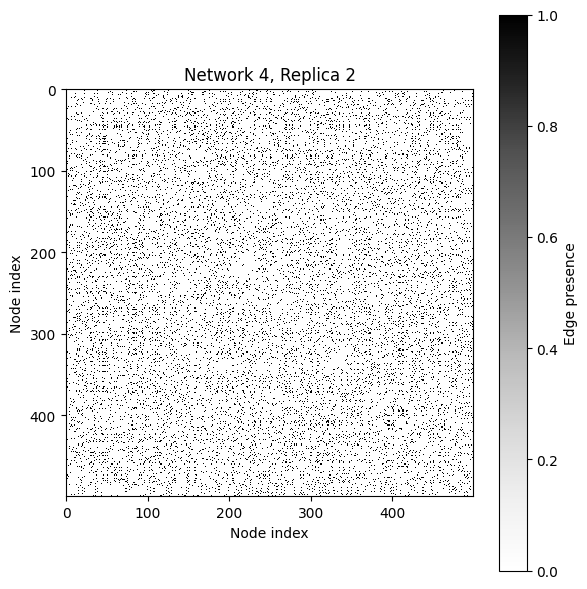

3 2


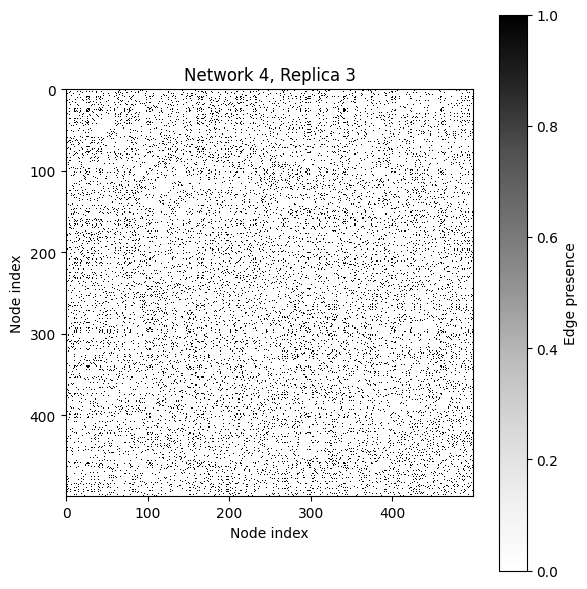

In [9]:
num_networks, num_replicas, N, _ = all_adj.shape

for i in range(num_networks):
    for r in range(num_replicas):
        print(i, r)
        A = all_adj[i, r]

        plt.figure(figsize=(6, 6))
        plt.imshow(A, cmap='Greys', interpolation='none')
        plt.colorbar(label='Edge presence')
        plt.title(f"Network {i+1}, Replica {r+1}")
        plt.xlabel("Node index")
        plt.ylabel("Node index")
        plt.tight_layout()
        plt.show()

TEST BUG: VARYING FREQ SPREAD


In [40]:
print(global_phasor.shape)
print(phase_data.shape)
print(np.abs(phase_data).shape)
dfa_scales()

(2001,)
(50, 2001)
(50, 2001)


array([ 32,  38,  45,  54,  64,  76,  91, 108, 128, 152, 181, 215, 256,
       304, 362, 431])

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate Kuramoto model for each value of k
k_values = np.linspace(1, 50, 25)
spread_values = np.linspace(3, 15, 10)

n_nodes = 50
n_oscillators = 50
sampling_rate = 200
frequency_spread = 2
weight_matrix = np.full((n_nodes, n_nodes), 5.0) # Fully connected !!
node_frequencies = [50.0] * n_nodes
use_cuda = True
time = 10  # simulate 10 seconds of activity

# Import the necessary module before using it (Assuming you have it available)
# from your_kuramoto_module import KuramotoFast

#for frequency_spread in spread_values:
order_results = []  # Reset for each frequency spread
variability_results = []  # Reset for each frequency spread

plv_results = []
dfa_values = []
fa_values = []

for k in k_values:
    # Simulate the Kuramoto model
    model_3 = KuramotoFast(n_nodes=n_nodes,
                            n_oscillators=n_oscillators,
                            k_list=[k] * n_nodes,
                            weight_matrix=weight_matrix,
                            node_frequencies=node_frequencies,
                            sampling_rate=sampling_rate,
                            frequency_spread=frequency_spread,
                            use_cuda=use_cuda)

    phase_data = model_3.simulate(time=time)
    phase_data = phase_data[:, 650:]  # remove transient
    n_timepoints = phase_data.shape[1]

    # Compute order and variability across time
    order = np.mean(np.abs(phase_data), axis=1)  # Average absolute value of phases
    variability = np.std(np.abs(phase_data), axis=1)  # Standard deviation of absolute value of phases

    # phase_data: (N_nodes, T) complex phasors
    inst_theta = np.angle(phase_data).T
    plv_mat = plv_matrix_vectorized(inst_theta)

    # Remove diagonal
    #Extract only upper triangle (no diagonal)

    np.fill_diagonal(plv_mat, 0)
    plv_order = plv_mat[np.triu_indices_from(plv_mat, k=1)].mean()
    plv_results.append(plv_order)


    # Plotting PLV matrix
    # plt.figure(figsize=(8, 6))
    # plt.imshow(plv_mat, cmap='hot', interpolation='nearest')
    # plt.colorbar(label='PLV')
    # plt.title(f'PLV Matrix for k={k:.2f} and PLV={plv_order:.2f}')
    # plt.xlabel('Node Index')
    # plt.ylabel('Node Index')
    # plt.show()

    # Compute DFA
    scales = dfa_scales() 
    module = np.abs(phase_data)
    global_phasor = module.mean(axis=0)       
    alpha = DFA(global_phasor)
    
    
    #scales = np.unique((2 ** np.arange(5, 9, 0.25)).astype(int))
    #F = [np.mean(calc_rms(y, sc)) for sc in scales]
    #coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
    #alpha = coeff[0]

    dfa_values.append(alpha[0])

    # Compute FA metric
    fa = FA_metric(global_phasor, scales)
    fa_values.append(fa[1])

    # Storing the values
    order_results.append(order)
    variability_results.append(variability)


Using device: CPU


Estimated FA exponent α = 0.659
Using device: CPU


Estimated FA exponent α = 0.722
Using device: CPU


Estimated FA exponent α = 0.674
Using device: CPU


Estimated FA exponent α = 0.750
Using device: CPU


...

Estimated FA exponent α = 0.314
Using device: CPU


Estimated FA exponent α = 0.337
Using device: CPU


Estimated FA exponent α = 0.413
Using device: CPU


Estimated FA exponent α = 0.443
Using device: CPU


Estimated FA exponent α = 0.339


Max variability at k = 11.208333333333332


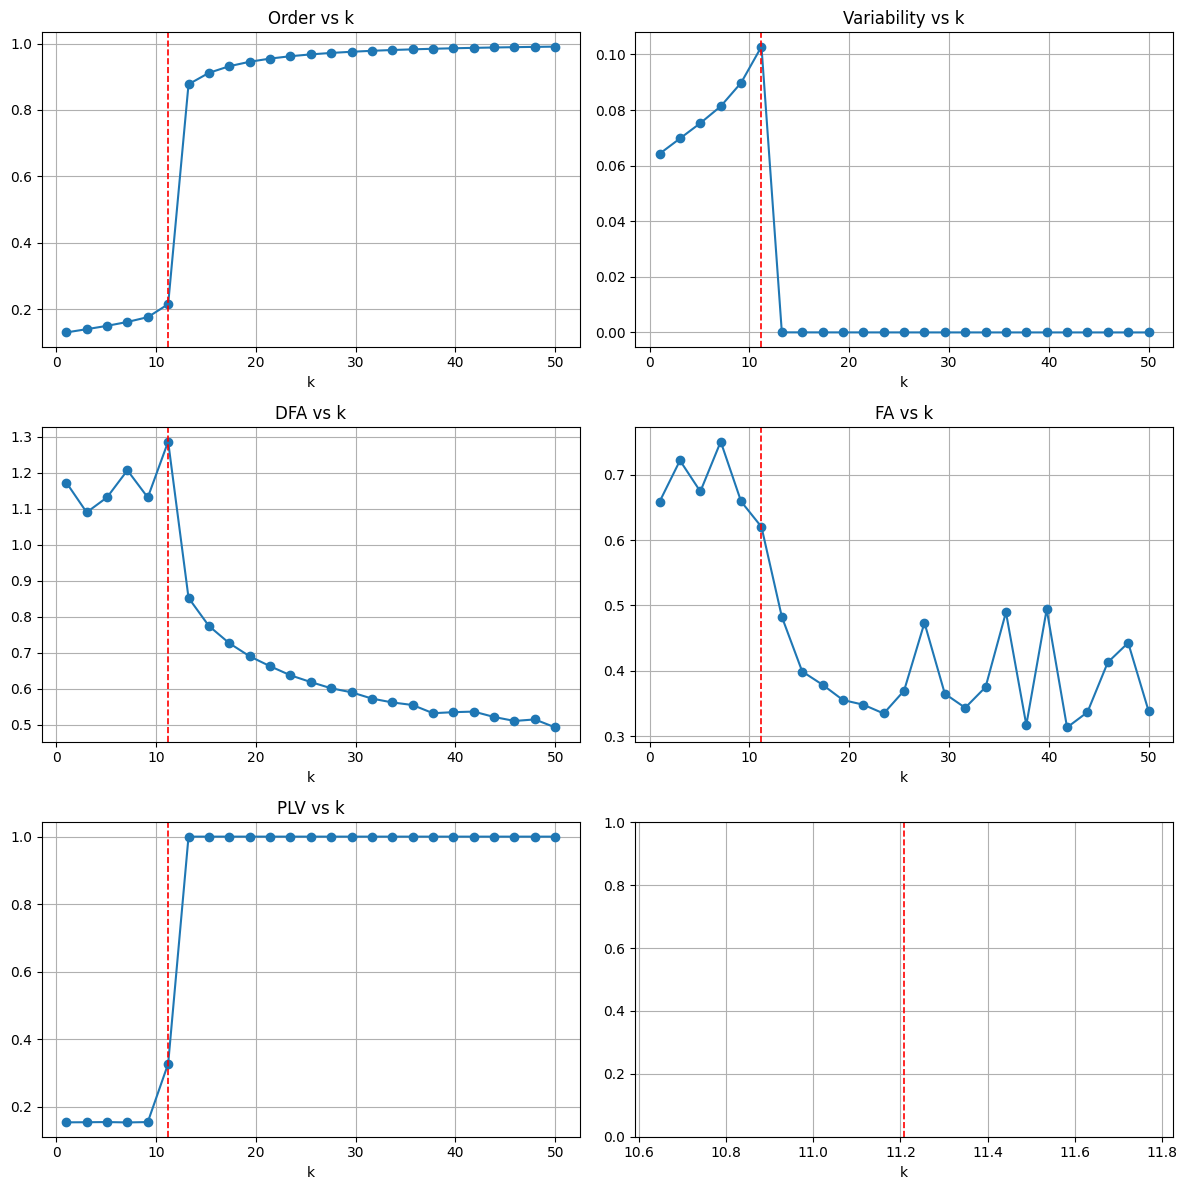

In [62]:
# Convert lists to arrays
order_results = np.array(order_results)            # (len(k_values), n_nodes)
variability_results = np.array(variability_results)
plv_order_results = np.array(plv_results)
dfa_values = np.array(dfa_values)
fa_values = np.array(fa_values)

# Compute means across nodes (for order + variability)
order_mean = order_results.mean(axis=1)
variability_mean = variability_results.mean(axis=1)

# ----- Determine the k where variability is maximal -----
idx_max = np.argmax(variability_mean)
k_max_var = k_values[idx_max]
print("Max variability at k =", k_max_var)

# ----- Plot all variables vs k -----
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.ravel()

axs[0].plot(k_values, order_mean, marker='o')
axs[0].set_title("Order vs k")

axs[1].plot(k_values, variability_mean, marker='o')
axs[1].set_title("Variability vs k")

axs[2].plot(k_values, dfa_values, marker='o')
axs[2].set_title("DFA vs k")

axs[3].plot(k_values, fa_values, marker='o')
axs[3].set_title("FA vs k")

axs[4].plot(k_values, plv_order_results, marker='o')
axs[4].set_title("PLV vs k")

# Add vertical line for max variability k
for ax in axs:
    ax.axvline(k_max_var, color='red', linestyle='--', linewidth=1.2)
    ax.set_xlabel("k")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [54]:
import numpy as np
import matplotlib.pyplot as plt

def compute_dfa_scales_from_cycles(
    T,               # total samples in time series
    sampling_rate,   # samples per second
    f_center,        # central frequency (Hz) used to define cycles
    min_cycles=10,   # minimum cycles at smallest scale (10-20 recommended)
    max_fraction=1/3,# max scale as fraction of data length (<= 1/3)
    n_scales=25,     # how many scales to propose (log spaced)
    min_windows=4    # discard scales that give fewer windows than this
):
    # samples per oscillatory cycle
    samples_per_cycle = sampling_rate / float(f_center)
    if samples_per_cycle < 1:
        raise ValueError("sampling_rate must be >= central frequency to get >=1 sample/cycle")

    # min & max scales in samples
    min_scale = max(2, int(np.ceil(min_cycles * samples_per_cycle)))
    max_scale_by_fraction = int(np.floor(T * max_fraction))
    max_scale_by_windows = int(np.floor(T / min_windows))  # ensure at least min_windows
    max_scale = min(max_scale_by_fraction, max_scale_by_windows)
    if max_scale <= min_scale:
        raise ValueError(f"max_scale ({max_scale}) <= min_scale ({min_scale}). Increase T or lower min_cycles/max_fraction.")

    # create log-spaced scales and make unique integers
    raw_scales = np.logspace(np.log10(min_scale), np.log10(max_scale), num=n_scales)
    scales = np.unique(np.round(raw_scales).astype(int))
    # compute number of non-overlapping windows for each scale
    n_windows = (T // scales)

    # keep only scales that give enough windows
    valid_mask = n_windows >= min_windows
    valid_scales = scales[valid_mask]
    valid_n_windows = n_windows[valid_mask]

    # final safety: ensure at least 5 valid scales
    if len(valid_scales) < 5:
        raise ValueError(f"Too few valid scales ({len(valid_scales)}). Try decreasing min_cycles or max_fraction, or increase data length T.")

    return {
        'min_scale': min_scale,
        'max_scale': max_scale,
        'all_scales': scales,
        'all_n_windows': n_windows,
        'scales': valid_scales,
        'n_windows': valid_n_windows,
        'samples_per_cycle': samples_per_cycle
    }


def plot_scale_diagnostics(dinfo, T):
    scales = dinfo['all_scales']
    n_windows = dinfo['all_n_windows']

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.semilogx(scales, n_windows, marker='o')
    plt.xlabel('scale (samples)')
    plt.ylabel('non-overlapping windows (T//scale)')
    plt.title('Windows per scale')
    plt.grid(True, which='both', ls='--')

    plt.subplot(1,2,2)
    valid = dinfo['scales']
    plt.semilogx(scales, np.isin(scales, valid).astype(int), 'o')
    plt.xlabel('scale (samples)')
    plt.title('Valid scales (1=kept, 0=rejected)')
    plt.grid(True, which='both', ls='--')
    plt.tight_layout()
    plt.show()


samples_per_cycle: 20.0
min_scale, max_scale: 200 333
proposed scales (kept): [200 204 207 211 215 218 222 226 230 234 238 243 247 251 256 260 265 270
 274 279 284 289 294 300 305 310 316 321 327 333]
windows per scale: [10  9  9  9  9  9  9  8  8  8  8  8  8  7  7  7  7  7  7  7  7  6  6  6
  6  6  6  6  6  6]


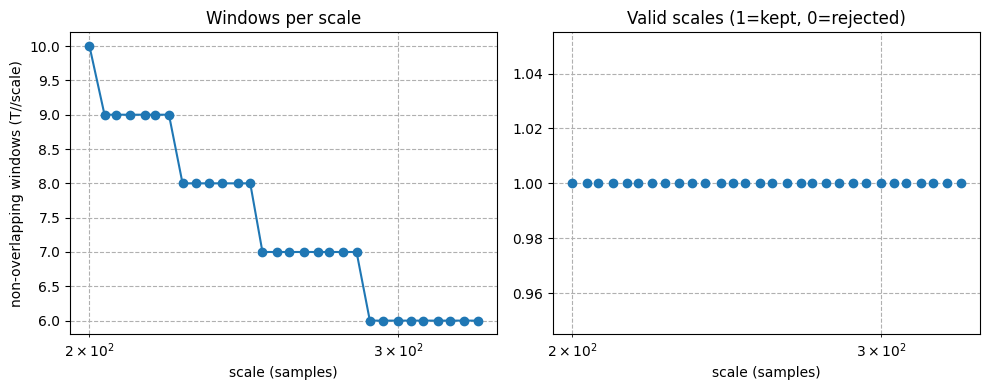

In [55]:
T = 2000
sr = 200
f0 = 10
dinfo = compute_dfa_scales_from_cycles(T, sr, f0, min_cycles=10, max_fraction=1/3, n_scales=30, min_windows=6)
print("samples_per_cycle:", dinfo['samples_per_cycle'])
print("min_scale, max_scale:", dinfo['min_scale'], dinfo['max_scale'])
print("proposed scales (kept):", dinfo['scales'])
print("windows per scale:", dinfo['n_windows'])
plot_scale_diagnostics(dinfo, T)


In [64]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 10)
n_nodes = 500
n_oscillators = 100
sampling_rate = 200
node_frequencies = [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order and variability across time
            order = np.mean(np.abs(phase_data), axis=1)  # Average absolute value of phases
            variability = np.std(np.abs(phase_data), axis=1)  # Standard deviation of absolute value of phases
        
            # 1. PLV: form phase_data: complex phasors
            inst_theta = np.angle(phase_data).T
            plv_mat = plv_matrix_vectorized(inst_theta)
        
            # Remove diagonal
            #Extract only upper triangle (no diagonal)
        
            np.fill_diagonal(plv_mat, 0)
            plv_order = plv_mat[np.triu_indices_from(plv_mat, k=1)].mean()
            
        
            # 2. Compute DFA
            scales = dfa_scales() 
            module = np.abs(phase_data)
            global_phasor = module.mean(axis=0)       
            alpha = DFA(global_phasor)
                       
                   
            # 3. Compute FA metric
            fa = FA_metric(global_phasor, scales)
            
            # Storing:
            
            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            #PLV
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # FA
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

            # DFA
            dfa_values[net_idx, rep_idx, k_idx] = alpha[0]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: CPU


KeyboardInterrupt: 

In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# ----------------------------------------------------
# Load adjacency matrices
# ----------------------------------------------------
data = np.load("adjacency_matrices.npz")
Adjacency_matrices = data["adjacency_matrices"]  # shape (4, 3, N, N)


# Getting the paramateteds
num_networks, num_replicas, _, _ = Adjacency_matrices.shape

# ----------------------------------------------------
# Define simulation parameters
# ----------------------------------------------------
k_values = np.linspace(1, 50, 25)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
node_frequencies = np.random.uniform(5, 12, n_nodes) # [10.0] * n_nodes
frequency_spread = 3
use_cuda = False
sim_time = 30  # seconds

# ----------------------------------------------------
# Initialize results containers
# ----------------------------------------------------
order_results = np.zeros((num_networks, num_replicas, len(k_values), n_nodes))
variability_results = np.zeros_like(order_results)
plv_results = np.zeros((num_networks, num_replicas, len(k_values)))
dfa_values = np.zeros_like(plv_results)
fa_values = np.zeros_like(plv_results)

# ----------------------------------------------------
# Main simulation loops
# ----------------------------------------------------
for net_idx in range(num_networks):
    print("network #: ", net_idx)
    for rep_idx in range(num_replicas):
        A = Adjacency_matrices[net_idx, rep_idx]

        print(f"Network {net_idx+1}/{num_networks}, Replica {rep_idx+1}/{num_replicas}")

        for k_idx, k in enumerate(k_values):
            print(f"  Running k = {k:.2f}")

            # Build model
            model_3 = KuramotoFast(
                n_nodes=n_nodes,
                n_oscillators=n_oscillators,
                k_list=[k]*n_nodes,
                weight_matrix = A,
                node_frequencies=node_frequencies,
                sampling_rate=sampling_rate,
                frequency_spread=frequency_spread,
                use_cuda=True,
            )

            # Run simulation
            phase_data = model_3.simulate(time=sim_time, random_seed=42) # RECONSTRUCTING THE SIGNAL
            phase_data = phase_data[:, 2000:]  # remove transient
            n_timepoints = phase_data.shape[1]

            # Compute order & variability
            order = np.mean(np.abs(phase_data), axis=1)
            variability = np.std(np.abs(phase_data), axis=1)

            order_results[net_idx, rep_idx, k_idx, :] = order
            variability_results[net_idx, rep_idx, k_idx, :] = variability

            # Compute PLV matrix
            plv_matrix = np.zeros((n_nodes, n_nodes))
            for i in range(n_nodes):
                for j in range(i, n_nodes):
                    plv_val = plv_func(phase_data[i, :], phase_data[j, :])
                    plv_matrix[i, j] = plv_matrix[j, i] = plv_val

            plv_order = np.mean(plv_matrix)
            plv_results[net_idx, rep_idx, k_idx] = plv_order

            # Compute DFA
            x = np.mean(phase_data, axis=0)
            y = calc_detrened(x)
            scale_exp_range = np.arange(5, 9, 0.25)
            scales = (2 ** scale_exp_range).astype(int)
            F = [np.mean(calc_rms(y, sc)) for sc in scales]
            coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
            alpha = coeff[0]
            dfa_values[net_idx, rep_idx, k_idx] = alpha

            # Compute FA metric
            fa = FA_metric(y, scales)
            fa_values[net_idx, rep_idx, k_idx] = fa[1]

# ----------------------------------------------------
# Convert results and save
# ----------------------------------------------------
np.savez_compressed(
    "kuramoto_results29octRandom.npz",
    order_results=order_results,
    variability_results=variability_results,
    plv_results=plv_results,
    dfa_values=dfa_values,
    fa_values=fa_values,
)
print("Simulation complete and results saved")


network #:  0
Network 1/4, Replica 1/3
  Running k = 1.00
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.436
  Running k = 3.04
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.430
  Running k = 5.08
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.528
  Running k = 7.12
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.615
  Running k = 9.17
Using device: GPU (CUDA/ROCm)


...

Estimated FA exponent α = 0.451
  Running k = 33.67
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.470
  Running k = 35.71
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.486
  Running k = 37.75
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.492
  Running k = 39.79
Using device: GPU (CUDA/ROCm)


Kuramoto model is running...:  30%|███       | 1828/6000 [00:14<00:33, 125.93it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
l

NameError: name 'l' is not defined